<a href="https://colab.research.google.com/github/sankeawthong/Project-1-Lita-Chatbot/blob/main/Demand%20Forecasting%20(demo).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Store Item Demand Forecasting
**Objective:** Predict the next 3 months of item-level sales across different store locations

## 1. Business Understanding

### Assumptions:
- `sales` is interpreted as the number of units sold per day rather than monetary sales. This is based on the integer values and the scale of the sales data
- Historical sales patterns can help predict future sales
- Store and item differences affect sales demand

### Data Dictionary
#### train.csv

| Column  | Data Type | Description                                                | Role    |
| ------- | --------- | ---------------------------------------------------------- | ------- |
| `date`  | datetime  | Date of the sales record                                   | Time    |
| `store` | integer   | Store identifier                                           | Feature |
| `item`  | integer   | Item identifier                                            | Feature |
| `sales` | integer   | Number of units sold for the item at the store on that day | Target  |

#### test.csv
| Column  | Data Type | Description                              | Role       |
| ------- | --------- | ---------------------------------------- | ---------- |
| `id`    | integer   | Unique identifier for each test record   | Identifier |
| `date`  | datetime  | Date for which sales need to be forecast | Time       |
| `store` | integer   | Store identifier                         | Feature    |
| `item`  | integer   | Item identifier                          | Feature    |


## Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

import warnings
warnings.filterwarnings('ignore')

SEED = 42

## 2. Data Understanding & Exploration

### 2.1 Data Understanding

In [8]:
train = pd.read_csv('train.csv', parse_dates=['date'])
test = pd.read_csv('test.csv', parse_dates=['date'])

print(f"train: {train.shape}")
print(train.head(), "\n")

print(f"test: {test.shape}")
print(test.head())

train: (913000, 4)
        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10 

test: (45000, 4)
   id       date  store  item
0   0 2018-01-01      1     1
1   1 2018-01-02      1     1
2   2 2018-01-03      1     1
3   3 2018-01-04      1     1
4   4 2018-01-05      1     1


#### Data Type check

In [9]:
print(f"Train dtypes:\n{train.dtypes}\n")
print(f"Test dtypes:\n{test.dtypes}")

Train dtypes:
date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

Test dtypes:
id                int64
date     datetime64[ns]
store             int64
item              int64
dtype: object


#### Date Range Check

In [10]:
print(f"Train date range: {train['date'].min()} - {train['date'].max()}")
print(f"Test  date range: {test['date'].min()} - {test['date'].max()}")

Train date range: 2013-01-01 00:00:00 - 2017-12-31 00:00:00
Test  date range: 2018-01-01 00:00:00 - 2018-03-31 00:00:00


#### Store and Item Coverage Check

In [11]:
print(f"Num of stores in Train: {train['store'].nunique()} | Test: {test['store'].nunique()}")
print(f"Num of items in Train: {train['item'].nunique()} | Test: {test['item'].nunique()}")

Num of stores in Train: 10 | Test: 10
Num of items in Train: 50 | Test: 50


Both the training and test datasets contain 10 stores and 50 items, so the test set doesn't include any unseen stores or items

### 2.2 Data Quality Check

In [12]:
def data_quality(df):
  print('Missing values')
  print(f"{df.isnull().sum()}\n")

  print(f"Duplicate rows: {df.duplicated(subset=['date', 'store', 'item']).sum()}")

print('Train set:')
data_quality(train)

print('\nTest set:')
data_quality(test)

Train set:
Missing values
date     0
store    0
item     0
sales    0
dtype: int64

Duplicate rows: 0

Test set:
Missing values
id       0
date     0
store    0
item     0
dtype: int64

Duplicate rows: 0


The train and test datasets contain no missing values or duplicate records, so no data cleaning is required.

#### Date Continuity Check

In [13]:
date_range = pd.date_range(train['date'].min(), train['date'].max())
missing_dates = date_range.difference(train['date'].unique())
print('Missing dates:', missing_dates)

Missing dates: DatetimeIndex([], dtype='datetime64[ns]', freq='D')


No missing dates were found. The dataset contains continuous daily dates

#### Sales Overview

In [14]:
print(train['sales'].describe())
print(f"\nNum of Negative sales: {(train['sales'] < 0).sum()}")
print(f"Num of 0 sales: {(train['sales'] == 0).sum()}")

count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

Num of Negative sales: 0
Num of 0 sales: 1


Sales range from 0 to 231 units, with an average of 52.25 units. There are no negative values and only one record with 0 sales. The data is slightly right-skewed because the mean is higher than the median.

#### Outlier Check

In [15]:
Q1 = train['sales'].quantile(0.25)
Q3 = train['sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[(train['sales'] < lower_bound) | (train['sales'] > upper_bound)]

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Num of outliers: {len(outliers)} ({len(outliers) / len(train) * 100:.2f}%) ")

Lower bound: -30.0
Upper bound: 130.0
Num of outliers: 11967 (1.31%) 


Only 1.31% of the data are potential outliers. The minimum sales value is 0, so no values can be below the lower bound of -30. Therefore, all potential outliers have sales above 130. I kept these values because they may represent real high-demand periods.

### 2.3 EDA

#### Average Daily Sales by Store

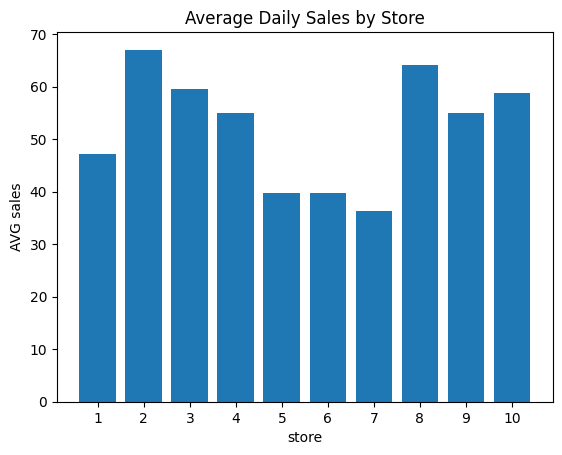

store
7     36.363735
6     39.733516
5     39.770164
1     47.268379
4     54.902946
9     55.049025
10    58.709288
3     59.530602
8     64.142048
2     67.033165
Name: sales, dtype: float64


In [16]:
store_mean = train.groupby('store')['sales'].mean()

plt.bar(store_mean.index, store_mean)
plt.title('Average Daily Sales by Store')
plt.xlabel('store')
plt.ylabel('AVG sales')
plt.xticks(range(1, 11))
plt.show()

print(store_mean.sort_values())

**Insight:** The average sales are clearly different across stores. The best-selling store and the lowest-selling store have a large difference in sales. Therefore, store should be considered an important feature for the forecasting model.

#### Average Daily Sales by Item

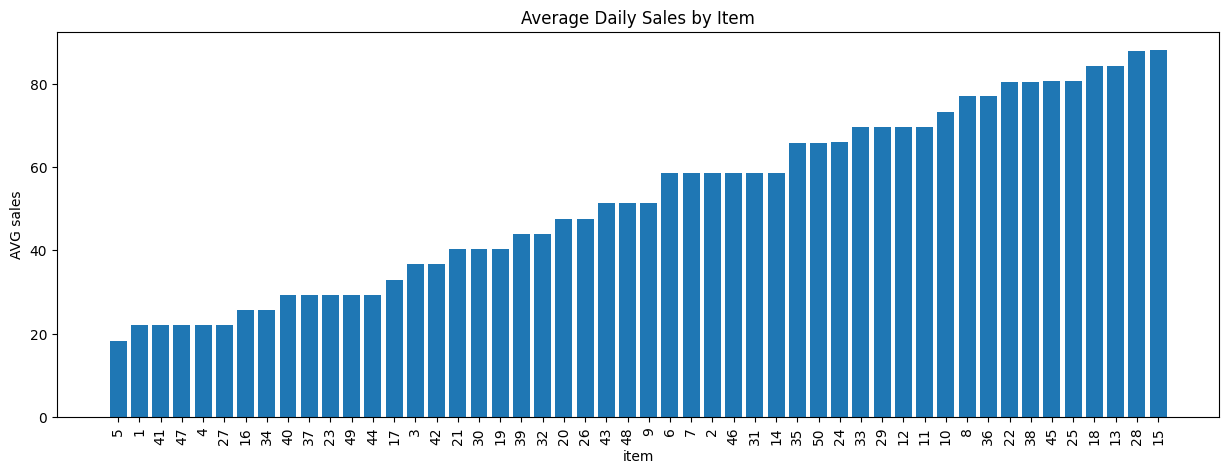

In [17]:
item_mean = train.groupby('item')['sales'].mean().sort_values()

plt.figure(figsize=(15, 5))
plt.bar(item_mean.index.astype(str), item_mean.values)
plt.title('Average Daily Sales by Item')
plt.xlabel('item')
plt.ylabel('AVG sales')
plt.xticks(rotation=90)
plt.show()

**Insight:** The average daily sales are different across items. Some items have higher average sales, while some items have lower average sales. This shows that each item has a different level of demand. Therefore, store should be considered an important feature for the forecasting model.


#### Store-Item Sales Analysis


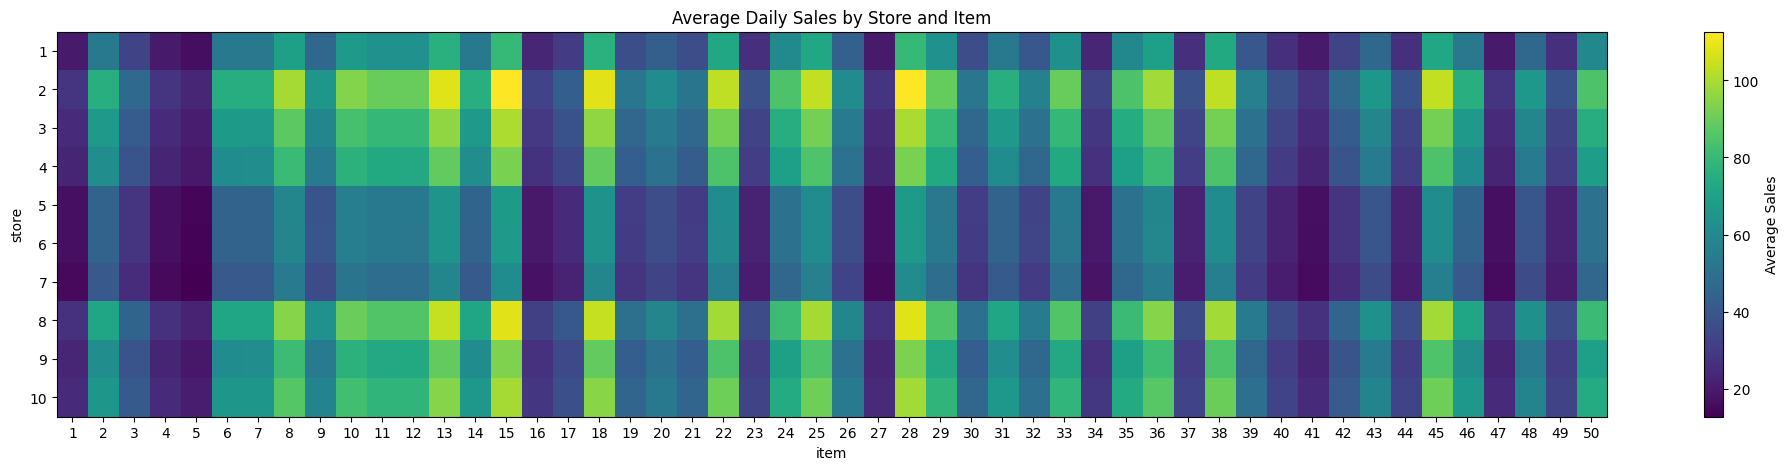

Best-selling item for each store:
       item  average_sales
store                     
1        15      79.680723
2        28     112.638007
3        15     100.423330
4        15      92.653888
5        15      66.987404
6        15      66.668675
7        15      61.139102
8        15     108.047645
9        15      93.137459
10       15      98.990690


In [18]:
store_item_mean = train.groupby(['store', 'item'])['sales'].mean().unstack()

plt.figure(figsize=(25, 5))

plt.imshow(store_item_mean, aspect='auto')

plt.title('Average Daily Sales by Store and Item')
plt.xlabel('item')
plt.ylabel('store')

plt.xticks(range(len(store_item_mean.columns)), store_item_mean.columns)
plt.yticks(range(len(store_item_mean.index)), store_item_mean.index)

plt.colorbar(label='Average Sales')
plt.show()

# Best-selling item for each store
best_item = store_item_mean.idxmax(axis=1)
best_sales = store_item_mean.max(axis=1)

print('Best-selling item for each store:')
print(pd.DataFrame({
    'item': best_item,
    'average_sales': best_sales
}))

**Insight:** Item 15 is the best-selling item in 9 out of 10 stores. This shows that sales depend on both the store and the item.

#### Sales Distribution

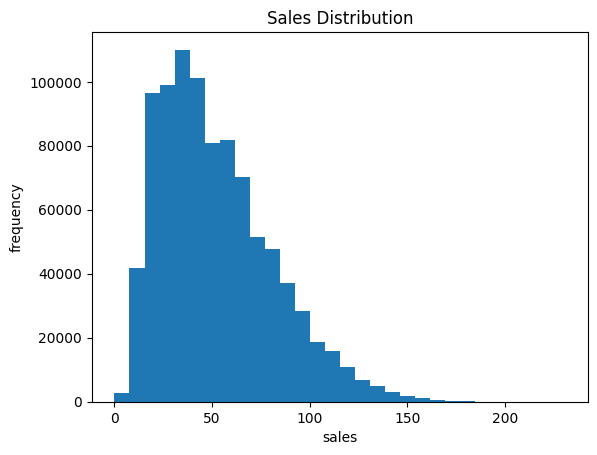

In [19]:
plt.hist(train['sales'], bins=30)

plt.title('Sales Distribution')
plt.xlabel('sales')
plt.ylabel('frequency')

plt.show()

**Insight:** Most sales values are relatively low, so the prediction model should consider the right-skewed distribution of the data

### 2.4 Time Series Analysis

#### Overall Sales Trend Over Time

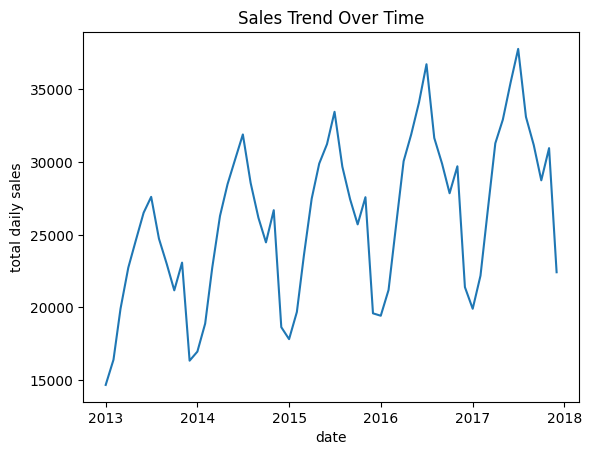

In [20]:
daily_total = train.groupby('date')['sales'].sum()
monthly_avg = daily_total.resample('MS').mean()

plt.plot(monthly_avg.index, monthly_avg.values)
plt.title('Sales Trend Over Time')
plt.xlabel('date')
plt.ylabel('total daily sales')
plt.show()

**Insight:** Overall sales increased from 2013 to 2017. There is also a seasonal pattern, with sales peaking in the middle of the year and dropping to the lowest levels at the beginning and end of the year.

#### Weekly Seasonality

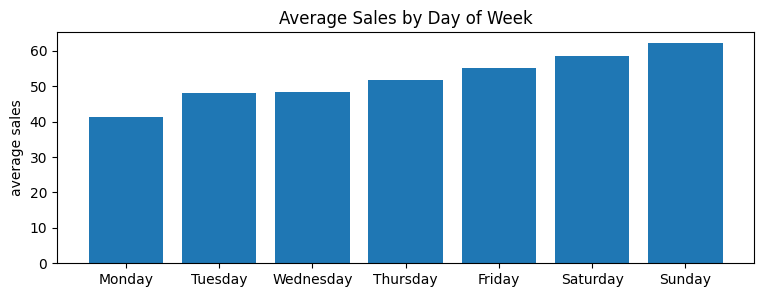

dayofweek_name
Monday       41.429638
Tuesday      48.225908
Wednesday    48.368506
Thursday     51.723218
Friday       55.157249
Saturday     58.662697
Sunday       62.143333
Name: sales, dtype: float64


In [21]:
train['dayofweek_name'] = train['date'].dt.day_name()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = train.groupby('dayofweek_name')['sales'].mean().reindex(order)

plt.figure(figsize=(9, 3))
plt.bar(day_avg.index, day_avg.values)
plt.title('Average Sales by Day of Week')
plt.ylabel('average sales')
plt.show()
print(day_avg)

**Insight:** Sales on weekends are clearly higher than on weekdays. This shows a weekly seasonality pattern. So, I should create `dayofweek` and `is_weekend` as features.

#### Monthly Seasonality

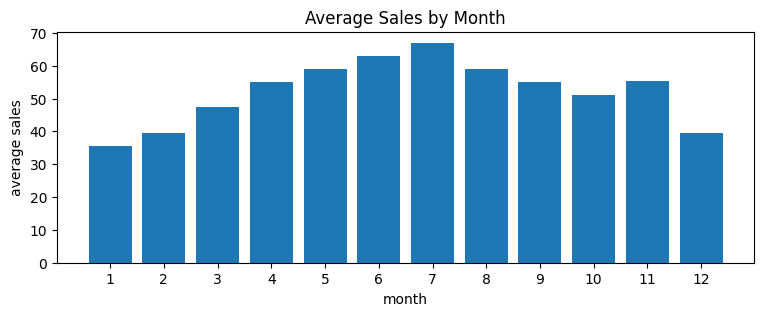

Overall Average Sales: 52.25
date
1     35.524503
2     39.378397
3     47.305574
4     55.152893
5     59.128219
6     63.025480
7     66.998619
8     59.105226
9     55.072760
10    51.193806
11    55.218080
12    39.365265
Name: sales, dtype: float64


In [22]:
month_avg = train.groupby(train['date'].dt.month)['sales'].mean()

plt.figure(figsize=(9, 3))
plt.bar(month_avg.index, month_avg.values)
plt.title('Average Sales by Month')
plt.xlabel('month')
plt.ylabel('average sales')
plt.xticks(range(1, 13))
plt.show()

print(f"Overall Average Sales: {train["sales"].mean():.2f}")
print(month_avg)

**Insight:** Sales change across different months. Sales are highest in June - July and lowest (lower than average) in January-March and December. Therefore, month should be included as a feature.

#### Yearly Pattern of January-March Sales
Since the objective is to predict January-March 2018, I check whether the same months in different years have similar patterns for lag features.

date
2013    34.037844
2014    39.097889
2015    40.772911
2016    44.137956
2017    45.807600
Name: sales, dtype: float64


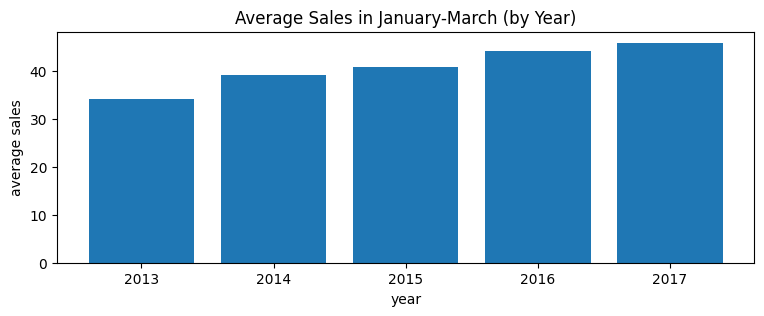

In [23]:
jan_mar = train[train['date'].dt.month <= 3]
jan_mar_by_year = jan_mar.groupby(jan_mar['date'].dt.year)['sales'].mean()
print(jan_mar_by_year)

plt.figure(figsize=(9, 3))
plt.bar(jan_mar_by_year.index, jan_mar_by_year.values)

plt.title('Average Sales in January-March (by Year)')
plt.xlabel('year')
plt.ylabel('average sales')
plt.show()

**Insight:** The average sales in January-March show a similar pattern each year. They are always lower than the overall average and increase over the years. This means that sales from the same period in the previous year could help predict sales. So, I can create a yearly lag feature such as `lag_364`

## 3.Data Cleaning & Preparation

### 3.1 Lag Feature Selection
I selected lags longer than 90 days because I want to use actual data to calculate the features throughout the forecast period.This helps avoid using predicted values, which can lead to accumulated errors, and filling in missing lag values.   
I selected candidate lags that match the seasonal patterns: 3 months (91 days), 6 months (182 days), and 1 year (364/365 days)   
I then used ACF to check which lags have stronger relationships with sales.

<Figure size 1200x500 with 0 Axes>

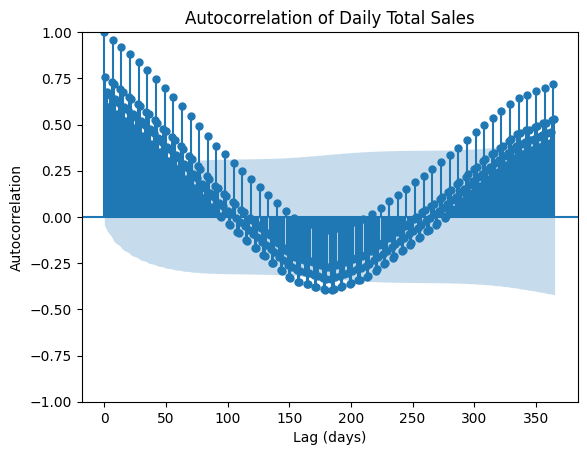

ACF of candidate lags:
lag  91: 0.3843
lag 182: -0.0702
lag 364: 0.7184
lag 365: 0.5298

Top 10 feasible lags (>90 days):
lag 364: 0.7184
lag 357: 0.6996
lag 350: 0.6806
lag 343: 0.6617
lag 336: 0.6421
lag 329: 0.6090
lag 322: 0.5718
lag 315: 0.5348
lag 365: 0.5298
lag 363: 0.5247


In [24]:
acf_values = acf(daily_total, nlags=365)

plt.figure(figsize=(12, 5))
plot_acf(daily_total, lags=365, alpha=0.05)
plt.title('Autocorrelation of Daily Total Sales')
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.show()

# Check ACF of selected candidate lags
candidate_lags = [91, 182, 364, 365]
print('ACF of candidate lags:')
for lag in candidate_lags:
    print(f'lag {lag:>3}: {acf_values[lag]:.4f}')

# Top 10 feasible lags (>90 days)
lags = range(91, 366)
top_lags = sorted(lags, key=lambda lag: abs(acf_values[lag]), reverse=True)[:10]
print('\nTop 10 feasible lags (>90 days):')
for lag in top_lags:
    print(f'lag {lag:>3}: {acf_values[lag]:.4f}')

**Insight**   
The results show strong **weekly seasonality**. The ACF slowly goes down, becomes negative around the middle of the year, and goes up again near the end of the year, showing a **repeating seasonal pattern** in sales.

**Conclusion**  
- **Lag 182** has very low autocorrelation, so I don't use it
- **Lag 364 and lag 365** have higher autocorrelation, with lag 364 being higher. Lag 364 also matches the same day of the week because 364 = 52 x 7 days.
- So, I choose `lag_364` as the main candidate and also keep `lag_91` because it has positive autocorrelation

### 3.2 Feature Engineering
#### Prepare Data for Feature Engineering
Since test data does not have `sales`, I temporarily combine train and test data to create lag features. For allows `shift()` to use actual sales from train when calculating `lag_91` and `lag_364` for the test period.

In [25]:
train_fe = train.drop(columns=['dayofweek_name']).copy()
train_fe['is_test'] = 0

test_fe = test.copy()
test_fe['is_test'] = 1

full = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)
full = full.sort_values(['store', 'item', 'date']).reset_index(drop=True)

print(full.shape)
full.head()

(958000, 6)


,date,store,item,sales,is_test,id
0,2013-01-01,1,1,13.0,0,NaN
1,2013-01-02,1,1,11.0,0,NaN
2,2013-01-03,1,1,14.0,0,NaN
3,2013-01-04,1,1,13.0,0,NaN
4,2013-01-05,1,1,10.0,0,NaN


#### Create Calendar and Lag Features

In [26]:
# Calendar Features
full['year'] = full['date'].dt.year
full['month'] = full['date'].dt.month
full['dayofweek'] =  full['date'].dt.dayofweek
full['is_weekend'] = full['dayofweek'].isin([5,6]).astype(int)

# lag Features
LAGS = [91, 364]
for lag in LAGS:
    full[f'lag_{lag}'] = full.groupby(['store', 'item'])['sales'].shift(lag)

full.tail()

,date,store,item,sales,is_test,id,year,month,dayofweek,is_weekend,lag_91,lag_364
957995,2018-03-27,10,50,NaN,1,44995.0,2018,3,1,0,41.0,60.0
957996,2018-03-28,10,50,NaN,1,44996.0,2018,3,2,0,63.0,73.0
957997,2018-03-29,10,50,NaN,1,44997.0,2018,3,3,0,59.0,68.0
957998,2018-03-30,10,50,NaN,1,44998.0,2018,3,4,0,74.0,69.0
957999,2018-03-31,10,50,NaN,1,44999.0,2018,3,5,1,62.0,101.0


#### Split Data and Check Lag Features
I split the data back into train and test sets and check that `lag_91` and `lag_364` have no missing values. This confirms that the selected lags always use actual sales data from the training period.

In [27]:
train_feat = full[full['is_test'] == 0].drop(columns=['is_test']).copy()
test_feat = full[full['is_test'] == 1].drop(columns=['is_test', 'sales']).copy()
test_feat['id'] = test_feat['id'].astype(int)

print("Missing values in lag features:")
print(test_feat[[f'lag_{l}' for l in LAGS]].isna().sum())

Missing values in lag features:
lag_91     0
lag_364    0
dtype: int64


In [28]:
FEATURES_CAL = ['store', 'item', 'year', 'month', 'dayofweek', 'is_weekend']
FEATURES_LAG = FEATURES_CAL + ['lag_91', 'lag_364']

for c in ['store', 'item']:
  train_feat[c] = train_feat[c].astype('category')
  test_feat[c] = test_feat[c].astype('category')

train_feat.tail()

,date,store,item,sales,id,year,month,dayofweek,is_weekend,lag_91,lag_364
957905,2017-12-27,10,50,63.0,NaN,2017,12,2,0,80.0,43.0
957906,2017-12-28,10,50,59.0,NaN,2017,12,3,0,82.0,68.0
957907,2017-12-29,10,50,74.0,NaN,2017,12,4,0,90.0,63.0
957908,2017-12-30,10,50,62.0,NaN,2017,12,5,1,103.0,64.0
957909,2017-12-31,10,50,82.0,NaN,2017,12,6,1,99.0,69.0


### 3.3 Time-Based Validation Split
Since the test set has no sales values, I use a time based split to evaluate the model on a future 90-day period. To help simulate the real forecasting task and prevents data leakage from the future.

Train: 2013-12-31 -> 2016-12-31  
Validation: 2017-01-01 -> 2017-03-31





In [29]:
VSTART = pd.Timestamp('2017-01-01')
VEND = pd.Timestamp('2017-03-31')

model_data = train_feat.dropna(subset=['lag_91', 'lag_364']).copy()

tr = model_data[model_data['date'] < VSTART]
val = model_data[(model_data['date'] >= VSTART) & (model_data['date'] <= VEND)]

print("Train rows:", tr.shape[0])
print("Train date:", tr['date'].min(), "->", tr['date'].max())

print("\nValidation rows:", val.shape[0])
print("Validation date:", val['date'].min(), "->", val['date'].max())
print("Number of Validation days:", val['date'].nunique())

Train rows: 548500
Train date: 2013-12-31 00:00:00 -> 2016-12-31 00:00:00

Validation rows: 45000
Validation date: 2017-01-01 00:00:00 -> 2017-03-31 00:00:00
Number of Validation days: 90


**Note**   
- I use dropna to keep `lag_91` and `lag_364` complete. This removes some early data, but it avoids adding noise from imputing missing lag values.So, I accepted this trade-off because the removed data can still be used in Model 1
- I use Jan-Mar 2017 as the validation period because it matches the actual test period (Jan-Mar 2018). I also tried using Oct-Dec 2017, which gave me a better sMAPE because this period has higher average demand than Jan-Mar. So, I realized that the validation period should use the same months as the test period for a fair comparison

## 4. Model Selection & Experimenting

### 4.1 Evaluation Metrics
- MAE → the average number of units the model predicts incorrectly  
- RMSE → gives more weight to large prediction errors
- sMAPE → shows prediction error in %   
I use **sMAPE** as the primary metric because it allows comparison across store-item combinations with different demand levels, while MAE and RMSE provide additional information about the magnitude of prediction errors.

In [30]:
def evaluate(y_true, y_pred, name):
  mae = np.mean(np.abs(y_true - y_pred))
  rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
  denominator = np.abs(y_true) + np.abs(y_pred)
  smape = 200 * np.mean(np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator))

  print(
      f"{name}:   "
      f"MAE = {mae:.3f}  "
      f"RMSE  = {rmse:.3f}  "
      f"sMAPE = {smape:.3f}  "
  )
  return {
      'model': name,
      'MAE': mae,
      'RMSE': rmse,
      'sMAPE': smape
  }
results = []

### 4.2 Baseline Model
Seasonal Naive : Predict today's sales using the sales from the same day last year with lag_364. The model doesn't learn from the data. It directly uses past sales as the prediction

In [31]:
results.append(evaluate(val['sales'], val['lag_364'], 'Baseline Model'))

Baseline Model:   MAE = 7.524  RMSE  = 9.781  sMAPE = 19.154  


### 4.3 LightGBM Model 1  (Calendar + Store + Item)
This model uses year, month, day of week, store, and item to predict sales without using past sales values.

In [32]:
X_tr1 = tr[FEATURES_CAL]
y_tr1 = tr['sales']

X_val1 = val[FEATURES_CAL]
y_val1 = val['sales']

model1 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=SEED, verbosity=-1)
model1.fit(
    X_tr1, y_tr1,
    eval_set=[(X_val1, y_val1)],
    categorical_feature=['store', 'item'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Best iteration:", model1.best_iteration_)
pred1 = model1.predict(X_val1)
results.append(evaluate(y_val1, pred1, 'LightGBM Model 1 (Calendar + Store + Item)'))

Best iteration: 448
LightGBM Model 1 (Calendar + Store + Item):   MAE = 5.387  RMSE  = 7.041  sMAPE = 13.562  


### 4.4 LightGBM Model 2 (Calendar + Lag Features)
Adding historical sales (`lag_91`, `lag_364`) may help the model predict better.   
Since `lag_364` was selected as the main candidate, I use validation to check whether adding `lag_91` can improve the model enough to be useful.   
So, I compare two models:
*   Model 2A :  Calendar + lag_364  
*   Model 2B : Calendar + lag_91 + lag_364




#### Model 2A :  Calendar + lag_364  

In [33]:
FEATURES_2A = FEATURES_CAL + ['lag_364']

X_tr2a = tr[FEATURES_2A]
y_tr2a = tr['sales']

X_val2a = val[FEATURES_2A]
y_val2a = val['sales']

model2a = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=SEED, verbosity=-1)
model2a.fit(
    X_tr2a, y_tr2a,
    eval_set=[(X_val2a, y_val2a)],
    categorical_feature=['store', 'item'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Best iteration:", model2a.best_iteration_)
pred2a = model2a.predict(X_val2a)
results.append(evaluate(y_val2a, pred2a, 'LightGBM Model 2A (Calendar + lag_364)'))

Best iteration: 753
LightGBM Model 2A (Calendar + lag_364):   MAE = 5.363  RMSE  = 7.011  sMAPE = 13.499  


#### Model 2B : Calendar + lag_91 + lag_364

In [34]:
FEATURES_2B = FEATURES_CAL + ['lag_91', 'lag_364']

X_tr2b = tr[FEATURES_2B]
y_tr2b = tr['sales']

X_val2b = val[FEATURES_2B]
y_val2b = val['sales']

model2b = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=SEED, verbosity=-1)
model2b.fit(
    X_tr2b, y_tr2b,
    eval_set=[(X_val2b, y_val2b)],
    categorical_feature=['store', 'item'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Best iteration:", model2b.best_iteration_)
pred2b = model2b.predict(X_val2b)
results.append(evaluate(y_val2b, pred2b, 'LightGBM Model 2B (Calendar + lag_91 + lag_364)'))

Best iteration: 947
LightGBM Model 2B (Calendar + lag_91 + lag_364):   MAE = 5.357  RMSE  = 6.995  sMAPE = 13.498  


**Result:** The sMAPE scores of both models are very close (13.499 vs. 13.498). The difference is very small, so adding `lag_91` doesn't provide enough improvement to justify the extra complexity. So, I choose **Model 2A (Calendar + lag_364)** as the final Model 2.

#### Selected Feature Set for Tuning
I selected the Model 2A feature set (Calendar + lag_364) for hyperparameter tuning

In [35]:
FEATURES_SELECTED = FEATURES_2A

### 4.5 Hyperparameter Tuning

In [36]:
X_tr_tune = tr[FEATURES_SELECTED]
y_tr_tune = tr['sales']

X_val_tune = val[FEATURES_SELECTED]
y_val_tune = val['sales']

tuning_configs = [
    {'learning_rate': 0.03, 'num_leaves': 7},
    {'learning_rate': 0.03, 'num_leaves': 15},
    {'learning_rate': 0.03, 'num_leaves': 31},
    {'learning_rate': 0.03, 'num_leaves': 63},

    {'learning_rate': 0.05, 'num_leaves': 7},
    {'learning_rate': 0.05, 'num_leaves': 15},
    {'learning_rate': 0.05, 'num_leaves': 31},
    {'learning_rate': 0.05, 'num_leaves': 63},

    {'learning_rate': 0.10, 'num_leaves': 7},
    {'learning_rate': 0.10, 'num_leaves': 15},
    {'learning_rate': 0.10, 'num_leaves': 31},
    {'learning_rate': 0.10, 'num_leaves': 64}
]

tuning_results = []
tuning_models = []

for config in tuning_configs:

    model = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=config['learning_rate'],
        num_leaves=config['num_leaves'],
        random_state=SEED,
        verbosity=-1
    )

    model.fit(
        X_tr_tune,
        y_tr_tune,
        eval_set=[(X_val_tune, y_val_tune)],
        categorical_feature=['store', 'item'],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    pred = model.predict(X_val_tune)

    model_name = (
        f"lr={config['learning_rate']}, "
        f"num_leaves={config['num_leaves']}, "
        f"best_iter={model.best_iteration_}"
    )

    tuning_results.append(
        evaluate(y_val_tune, pred, model_name)
    )

    tuning_models.append(model)

best_config = int(np.argmin([r['sMAPE'] for r in tuning_results]))
print("\nBest result:", tuning_configs[best_config])
results.append({**tuning_results[best_config], 'model': 'Tuned LightGBM'})

lr=0.03, num_leaves=7, best_iter=2000:   MAE = 5.380  RMSE  = 7.024  sMAPE = 13.555  
lr=0.03, num_leaves=15, best_iter=1705:   MAE = 5.352  RMSE  = 6.994  sMAPE = 13.485  
lr=0.03, num_leaves=31, best_iter=1308:   MAE = 5.362  RMSE  = 7.011  sMAPE = 13.493  
lr=0.03, num_leaves=63, best_iter=993:   MAE = 5.381  RMSE  = 7.033  sMAPE = 13.535  
lr=0.05, num_leaves=7, best_iter=1865:   MAE = 5.335  RMSE  = 6.970  sMAPE = 13.448  
lr=0.05, num_leaves=15, best_iter=1082:   MAE = 5.353  RMSE  = 6.995  sMAPE = 13.483  
lr=0.05, num_leaves=31, best_iter=753:   MAE = 5.363  RMSE  = 7.011  sMAPE = 13.499  
lr=0.05, num_leaves=63, best_iter=551:   MAE = 5.384  RMSE  = 7.039  sMAPE = 13.538  
lr=0.1, num_leaves=7, best_iter=858:   MAE = 5.337  RMSE  = 6.973  sMAPE = 13.455  
lr=0.1, num_leaves=15, best_iter=516:   MAE = 5.351  RMSE  = 6.993  sMAPE = 13.484  
lr=0.1, num_leaves=31, best_iter=344:   MAE = 5.375  RMSE  = 7.023  sMAPE = 13.527  
lr=0.1, num_leaves=64, best_iter=285:   MAE = 5.387  RM

## 5. Evaluation
### 5.1 Model Evaluation

In [37]:
summary_df = pd.DataFrame(results)[['model', 'MAE', 'RMSE', 'sMAPE']]
summary_df

,model,MAE,RMSE,sMAPE
0,Baseline Model,7.524044,9.780995,19.153920
1,LightGBM Model 1 (Calendar + Store + Item),5.386662,7.041477,13.562021
2,LightGBM Model 2A (Calendar + lag_364),5.362870,7.010963,13.498539
3,LightGBM Model 2B (Calendar + lag_91 + lag_364),5.357119,6.995428,13.497813
4,Tuned LightGBM,5.334845,6.969948,13.447739


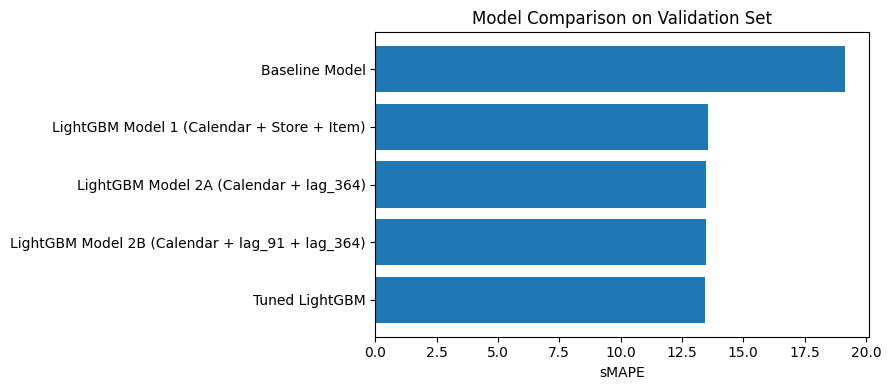

In [38]:
plt.figure(figsize=(9,4))
plt.barh(summary_df['model'], summary_df['sMAPE'])
plt.xlabel('sMAPE')
plt.title('Model Comparison on Validation Set')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Conclusion**: All LightGBM models perform better than the Baseline. The **Tuned LightGBM** performs the best, with the lowest MAE, RMSE, and sMAPE at 13.45%.

### 5.2 Error Analysis
I use predictions from the Tuned LightGBM on the validation set to see how the prediction errors are distributed
#### Error by Store

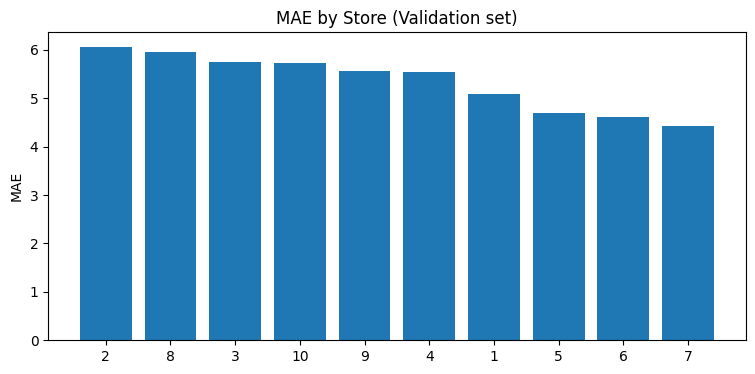

store
2     6.055493
8     5.943676
3     5.747834
10    5.720261
9     5.550460
4     5.535527
1     5.081557
5     4.686375
6     4.599070
7     4.428194
Name: abs_error, dtype: float64


In [39]:
final_tuned_model = tuning_models[best_config]

val_analysis = val.copy()
val_analysis['pred'] = final_tuned_model.predict(X_val_tune)
val_analysis['abs_error'] = np.abs(val_analysis['sales'] - val_analysis['pred'])

error_by_store = val_analysis.groupby('store')['abs_error'].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 4))
plt.bar(error_by_store.index.astype(str), error_by_store.values)
plt.title('MAE by Store (Validation set)')
plt.ylabel('MAE')
plt.show()
print(error_by_store)


**Insight:** Store 2 has the highest average error, while Store 7 has the lowest. This suggests that the model may have more difficulty predicting sales for some stores than others.

#### Error vs. Demand Level by Item
I check whether items with higher sales have larger prediction errors

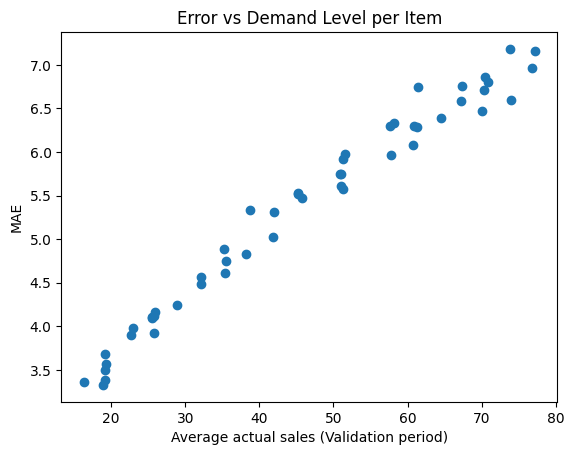

In [40]:
item_level = val_analysis.groupby('item').agg(mean_sales=('sales', 'mean'), mean_abs_error=('abs_error', 'mean'))
plt.scatter(item_level['mean_sales'], item_level['mean_abs_error'])
plt.xlabel('Average actual sales (Validation period)')
plt.ylabel('MAE')
plt.title('Error vs Demand Level per Item')
plt.show()

**Insight:** Higher average unit sales → higher MAE   
It means that items with higher demand have higher absolute errors.

#### Actual vs. Predicted Sales
Compare actual and predicted sales for Store 1, Item 1 to see how well the model follows the actual sales pattern over time.

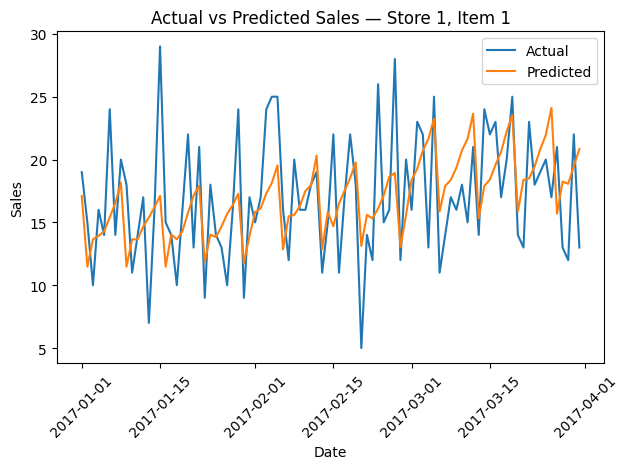

In [41]:
sample = val_analysis[(val_analysis['store'] == 1) & (val_analysis['item'] == 1)].sort_values('date')

plt.plot(sample['date'], sample['sales'], label='Actual')
plt.plot(sample['date'], sample['pred'], label='Predicted')

plt.title('Actual vs Predicted Sales — Store 1, Item 1')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**   
The model can predict the overall monthly sales trend quite well. However, it tends to under-predict on peak days and over-predict on low-sales days. This suggests that the model tends to predict closer to the average and may not capture sudden changes in daily sales. This is a limitation that could be improved with additional features, but the current model still performs well overall.



#### Bias Check (Signed Error)
`abs_error` shows the size of the errors, but it doesn't show which direction the errors go. So, I use signed error (`actual - predicted`) to check the direction of the errors.

Mean signed error: 1.3004
Mean actual sales: 45.81
Error as % of mean sales: 2.84%


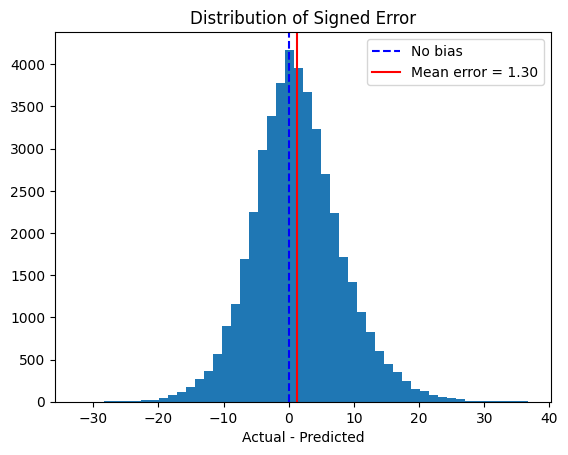

In [42]:
val_analysis['error'] = val_analysis['sales'] - val_analysis['pred']

mean_error = val_analysis['error'].mean()
mean_sales = val_analysis['sales'].mean()

print(f"Mean signed error: {mean_error:.4f}")
print(f"Mean actual sales: {mean_sales:.2f}")
print(f"Error as % of mean sales: {mean_error / mean_sales * 100:.2f}%")

plt.hist(val_analysis['error'], bins=50)

plt.axvline(0, color='blue', linestyle='--', label='No bias')
plt.axvline(mean_error, color='red', label=f'Mean error = {mean_error:.2f}')

plt.title('Distribution of Signed Error')
plt.xlabel('Actual - Predicted')
plt.legend()
plt.show()

**Result:** The mean signed error is 1.30, or about 2.84% of the mean actual sales. This means the model slightly under-predicts sales on average, but the difference is small.

#### Error by Forecast Horizon
Since the project forecasts 90 days at once using fixed features (`lag_364`) without recursive updates, I check whether the prediction error increases over the forecast period. This helps show whether the model becomes less accurate for longer forecast horizons.

horizon
Day 1-30     4.903363
Day 31-60    5.279447
Day 61-90    5.821724
Name: abs_error, dtype: float64


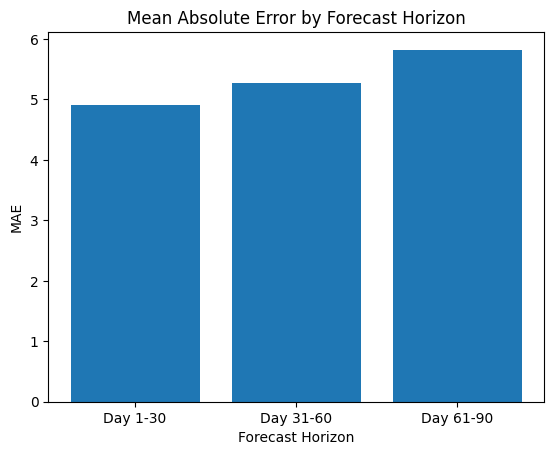

In [43]:
val_analysis['horizon'] = (val_analysis['date'] - VSTART).dt.days + 1

horizon_error = val_analysis.groupby(
    pd.cut(
        val_analysis['horizon'],
        bins=[0, 30, 60, 90],
        labels=['Day 1-30', 'Day 31-60', 'Day 61-90']
    )
)['abs_error'].mean()

print(horizon_error)

plt.bar(horizon_error.index, horizon_error.values)

plt.title('Mean Absolute Error by Forecast Horizon')
plt.xlabel('Forecast Horizon')
plt.ylabel('MAE')

plt.show()

**Insight:** The MAE increases from 4.90 in Day 1-30 to 5.82 in Day 61-90. This means the model becomes less accurate as the forecast period gets longer. This is an expected limitation of using fixed features for a long forecast period, but the model still performs well overall.

### 5.3 Feature Imprtance

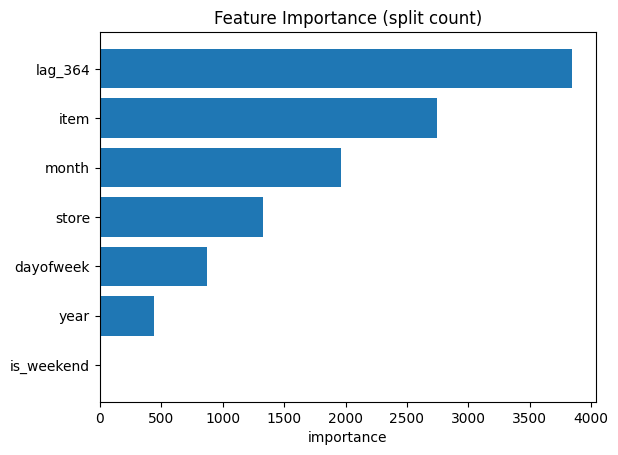

lag_364       3845
item          2747
month         1962
store         1324
dayofweek      871
year           438
is_weekend       3
dtype: int32


In [44]:
imp = pd.Series(final_tuned_model.feature_importances_, index=FEATURES_SELECTED).sort_values()

plt.barh(imp.index, imp.values)
plt.title('Feature Importance (split count)')
plt.xlabel('importance')
plt.show()
print(imp.sort_values(ascending=False))

**Insight:** lag_364 is the most important feature, indicating that sales from approximately one year earlier provide the strongest predictive signal. item, month, and store are also important, while is_weekend contributes very little to the model.

### 5.4 Final Model Selection

I selected **LightGBM (Calendar + lag_364, `learning_rate=0.05`, `num_leaves=7`)** because it achieved the lowest sMAPE (13.448) among the tested configurations. The lag_364 feature also has a clear meaning, as it compares sales with the same day in the previous year, supported by the ACF results and better day-of-week alignment.

### 5.5 Retrain Final Model on Full Training Data

In [45]:
final_n_estimators = final_tuned_model.best_iteration_
best_params = tuning_configs[best_config]
print("Final n_estimators:", final_n_estimators)
print("Final params:", best_params)

X_full = model_data[FEATURES_SELECTED]
y_full = model_data['sales']

final_model = lgb.LGBMRegressor(
    n_estimators=final_n_estimators,
    learning_rate=best_params['learning_rate'],
    num_leaves=best_params['num_leaves'],
    random_state=SEED, verbosity=-1,
)
final_model.fit(X_full, y_full, categorical_feature=['store', 'item'])
print("Number of training records:", X_full.shape[0])

Final n_estimators: 1865
Final params: {'learning_rate': 0.05, 'num_leaves': 7}
Number of training records: 731000


### 5.6 Forecast on Test Set

In [46]:
X_test = test_feat[FEATURES_SELECTED]
test_pred = final_model.predict(X_test)

test_pred = np.clip(test_pred, 0, None)

submission = test_feat[['id']].copy()
submission['sales'] = test_pred

submission.to_csv('submission.csv', index=False)
print("Submission shape:", submission.shape)
submission.head()

Submission shape: (45000, 2)


,id,sales
1826,0,11.981133
1827,1,14.117648
1828,2,14.406349
1829,3,15.157149
1830,4,16.104793


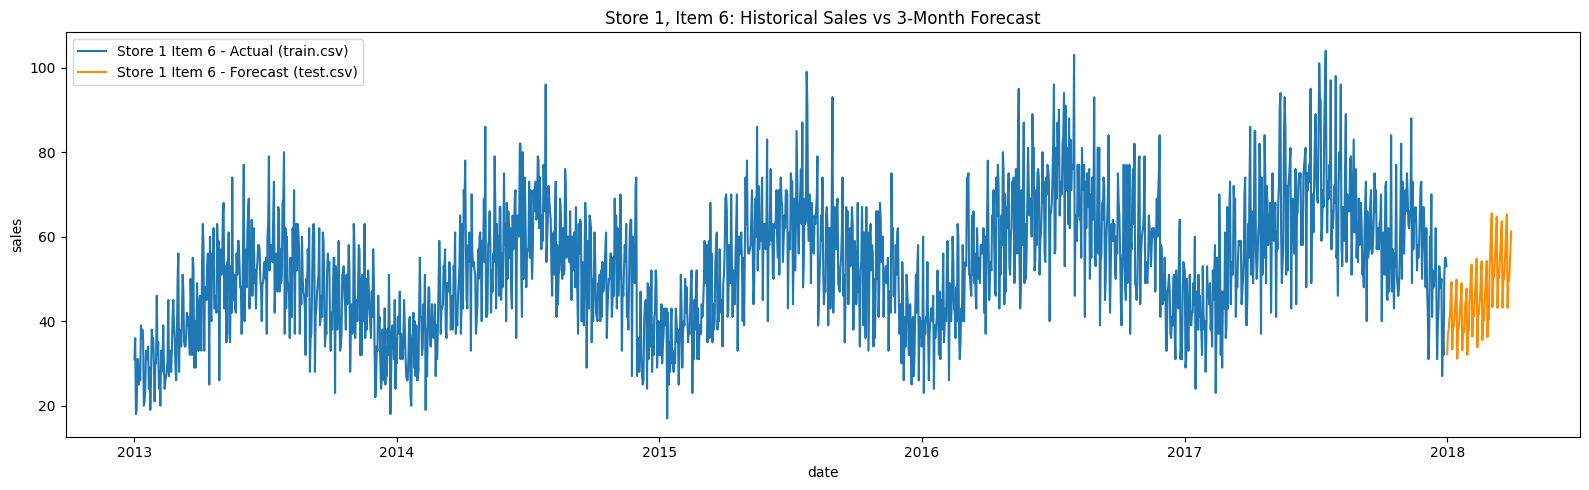

In [47]:
sample_store, sample_item = 1, 6

train_sample = train[(train['store'] == sample_store) & (train['item'] == sample_item)].sort_values('date')

forecast_sample = submission.merge(test[['id', 'date', 'store', 'item']], on='id')
forecast_sample = forecast_sample[
    (forecast_sample['store'] == sample_store) & (forecast_sample['item'] == sample_item)
].sort_values('date')

plt.figure(figsize=(16, 5))
plt.plot(train_sample['date'], train_sample['sales'], label=f'Store {sample_store} Item {sample_item} - Actual (train.csv)')
plt.plot(forecast_sample['date'], forecast_sample['sales'], label=f'Store {sample_store} Item {sample_item} - Forecast (test.csv)', color='darkorange')
plt.title(f'Store {sample_store}, Item {sample_item}: Historical Sales vs 3-Month Forecast')
plt.xlabel('date')
plt.ylabel('sales')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** The model can predict sales for Store 1, Item 6 in line with the historical trend and captures the yearly seasonality well. Sales are expected to increase from Jan to Mar 2018

### 5.7 Sanity Checking

In [48]:
print("Number of negative predictions:", (submission['sales'] < 0).sum())

print("\nPrediction Summary:")
print(submission['sales'].describe())

print("\nHistorical Sales Summary (full train.csv):")
print(train['sales'].describe())

Number of negative predictions: 0

Prediction Summary:
count    45000.000000
mean        46.012750
std         22.999529
min          7.184436
25%         27.196604
50%         42.701325
75%         60.801935
max        143.694477
Name: sales, dtype: float64

Historical Sales Summary (full train.csv):
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


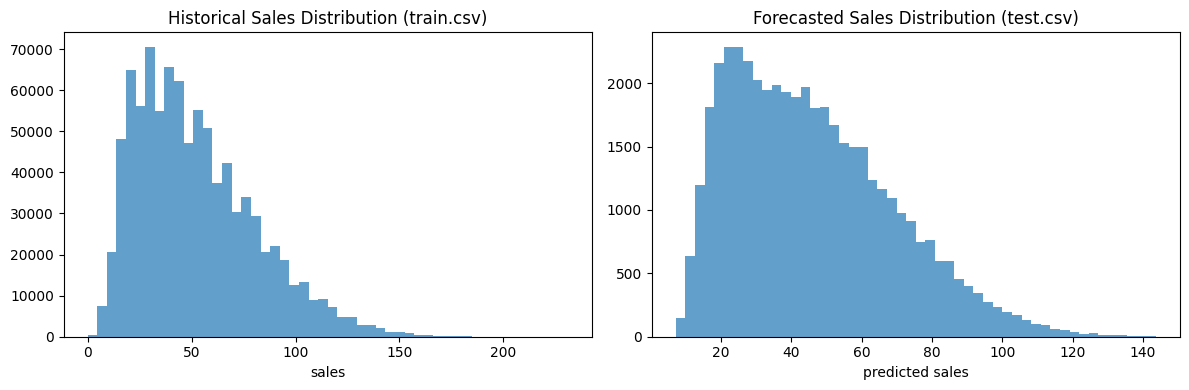

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['sales'], bins=50, alpha=0.7)
axes[0].set_title('Historical Sales Distribution (train.csv)')
axes[0].set_xlabel('sales')

axes[1].hist(submission['sales'], bins=50, alpha=0.7)
axes[1].set_title('Forecasted Sales Distribution (test.csv)')
axes[1].set_xlabel('predicted sales')
plt.tight_layout()
plt.show()


**Insight:** There are no negative predictions, and the predicted sales are within a reasonable range. The prediction mean (46.01) is slightly lower than the historical mean (52.25), which is reasonable because Jan-Mar usually has lower sales than the yearly average. Overall, the prediction distribution looks similar to the historical data.

## Business Insights & Conclusion
- **Store and item affect sales:** Average sales are different across stores, and the best-selling item is not the same for every store. Item 15 is the best-selling item in 9 out of 10 stores, while Store 2 sells Item 28 the most.
- **Sales have clear weekly and yearly patterns:** Sales are higher on weekends, usually peak around June-July, and are lower around January-March and December.
- **lag_364** is an important feature for prediction. It shows that sales have a clear yearly pattern that repeats from year to year.
- **Prediction errors are different across store-item pairs:** Items with higher sales usually have larger absolute errors. Also, the error increases slightly for longer forecast periods, which is useful to consider when planning inventory.